# Homework

## The goal is to predict fuel_efficiency_mpg

## Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
data = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv"
df = pd.read_csv(data)
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [3]:
features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
features

['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

## EDA

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

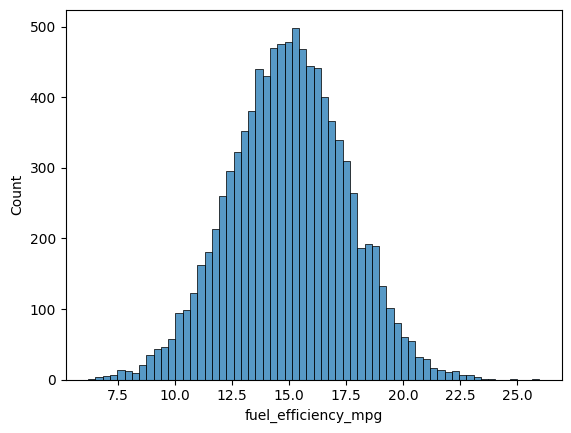

In [4]:
sns.histplot(df['fuel_efficiency_mpg'])

**Look at the fuel_efficiency_mpg variable. Does it have a long tail?**

*Doesn't have long tail, look like a perfect bell curve*

## Question 1

**There's one column with missing values. What is it?**

*Column with missing value is horsepower*

In [5]:
df[features].isna().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
dtype: int64

## Question 2

**What's the median for variable horsepower?**

*149*

In [6]:
df[features].describe().round()

,engine_displacement,horsepower,vehicle_weight,model_year
count,9704.0,8996.0,9704.0,9704.0
mean,200.0,150.0,3001.0,2011.0
std,49.0,30.0,498.0,7.0
min,10.0,37.0,953.0,2000.0
25%,170.0,130.0,2666.0,2006.0
50%,200.0,149.0,2993.0,2012.0
75%,230.0,170.0,3335.0,2017.0
max,380.0,271.0,4739.0,2023.0


### Prepare and split the dataset

In [7]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [8]:
n_val, n_test, n_train

(1940, 1940, 5824)

In [9]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)
idx

array([ 483, 7506, 8795, ..., 5390,  860, 7270], shape=(9704,))

In [10]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [11]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [12]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

y_train_log = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val_log = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test_log = np.log1p(df_test.fuel_efficiency_mpg.values)

In [13]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

## Question 3

- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 2 decimal digits using round(score, 2)
- Which option gives better RMSE?

In [14]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

### Fillna with 0

In [15]:
df_train[features].fillna(0).isna().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [16]:
X_train = df_train[features].fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

### RMSE with Fillna 0

In [17]:
def prepare_X(df):
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [18]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [19]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred).round(2)

np.float64(0.52)

### Fillna with Mean

In [20]:
df_train[features].mean()

engine_displacement     199.429945
horsepower              149.544764
vehicle_weight         3006.672919
model_year             2011.444712
dtype: float64

In [21]:
df_train[features].fillna(df_train[features].mean).isna().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [22]:
X_train = df_train[features].fillna(df_train[features].mean()).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

### RMSE with Fillna Mean

In [23]:
def prepare_X(df):
    df_num = df[features]
    df_num = df_num.fillna(df_num.mean())
    X = df_num.values
    return X

In [24]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [25]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred).round(2)

np.float64(0.46)

### Conclusion

Using original data (not log transformed), the result shows that fill missing values with mean value improve the RMSE compared to fill missing values with 0 value. 

RMSE with 0 value = 0.52
RMSE with mean value = 0.46

### Fillna with 0 log data

In [26]:
def prepare_X(df):
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [27]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [28]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train_log)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val_log, y_pred)

np.float64(0.0399792578229878)

### Fillna with mean log data

In [29]:
def prepare_X(df):
    df_num = df[features]
    df_num = df_num.fillna(df_num.mean())
    X = df_num.values
    return X

In [30]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [31]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train_log)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val_log, y_pred)

np.float64(0.03733069335596169)

### Conclusion using log data

Using log transformed data, the result shows that fill missing values with mean value improve the RMSE compared to fill missing values with 0 value. 

RMSE with 0 value = 0.039
RMSE with mean value = 0.037

## Refactoring the code for Question 3

In [32]:
## Choosing relevant features 
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

df = df[columns]

In [33]:
## Splitting and preparing the dataset

n = len(df)

n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [34]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [35]:
def train_linear_regression (X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

def prepare_X(df, fillna_value):
    df = df.fillna(fillna_value)
    X = df.values
    return X

def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

with mean

In [36]:
mean = df_train.horsepower.mean()

X_train = prepare_X(df_train, fillna_value=mean)
w_0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, fillna_value=mean)
y_pred = w_0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.4635965042344029)

with 0

In [37]:
mean = df_train.horsepower.mean()

X_train = prepare_X(df_train, fillna_value=0)
w_0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, fillna_value=0)
y_pred = w_0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5173782638841185)

## Question 4

- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 2 decimal digits.
- Which r gives the best RMSE?

In [38]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [39]:
for r in [0, 0.01, 1, 10, 100]:
    X_train = prepare_X(df_train, fillna_value=0)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    X_val = prepare_X(df_val, fillna_value=0)
    y_pred = w0 + X_val.dot(w)
    
    score = rmse(y_val, y_pred)

    print(r, w0, score.round(3))

0 28.827365474598718 0.517
0.01 24.926838421084422 0.517
1 1.7315979412398264 0.522
10 0.18306246622476907 0.523
100 0.01841801730804525 0.523


the answer = 0

## Question 5

- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

In [40]:
rmses= []

for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    
    n = len(df)
    
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.seed(s)
    np.random.shuffle(idx)

    df_shuffled = df.iloc[idx]

    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
    df_test = df_shuffled.iloc[n_train+n_val:].copy()

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X(df_train, fillna_value=0)
    w0, w = train_linear_regression(X_train, y_train)
    
    X_val = prepare_X(df_val, fillna_value=0)
    y_pred = w0 + X_val.dot(w)

    result = rmse(y_val, y_pred)
    print(s, result)

    rmses.append(result)

0 0.5206531296297207
1 0.5213388912866506
2 0.5228069974913666
3 0.5159516741255491
4 0.5109129460116937
5 0.5283406460212935
6 0.5313910658190373
7 0.509067038739038
8 0.5147399129482789
9 0.513186590829269


In [43]:
np.std(rmses)

np.float64(0.006989446427824928)

## Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

In [44]:
n = len(df)
    
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [48]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

X_full_train = prepare_X(df_full_train, fillna_value=0)
y_full_train = np.concatenate([y_train, y_val])

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

X_test = prepare_X(df_test, fillna_value=0)
y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)
print(score)

0.5156261299185628
